# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [2]:
fs = 1000
T = 1
t = np.linspace(0, T, int(fs * T), endpoint=False)

print(f"Длина массива времени: {len(t)} отсчётов")
print(f"Шаг дискретизации (период): {t[1] - t[0]:.5f} с")

Длина массива времени: 1000 отсчётов
Шаг дискретизации (период): 0.00100 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен 0.001 с. Частота и период связаны обратной пропорциональностью: Δt = 1/fs.

### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

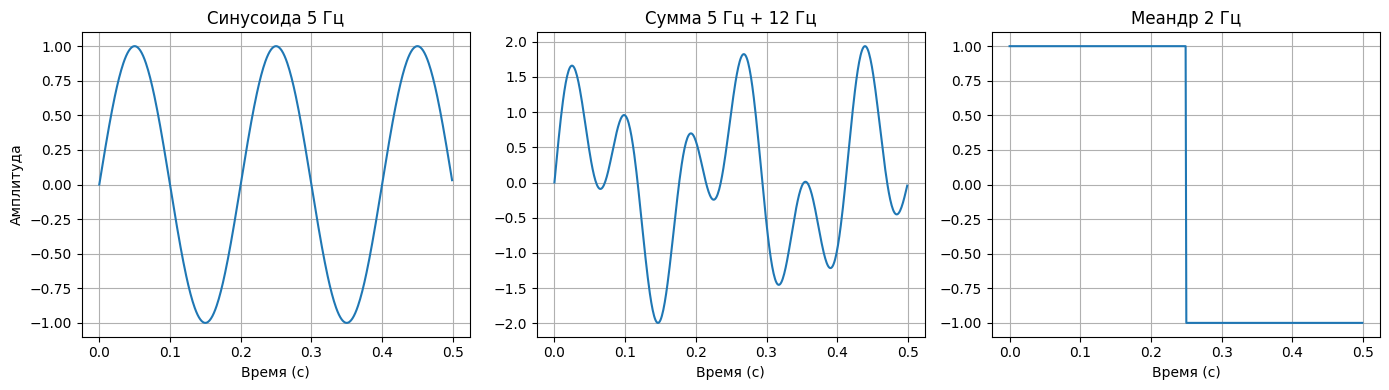

In [3]:
f1 = 5
sin5 = np.sin(2 * np.pi * f1 * t)

f2 = 12
sum_sin = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

meander = signal.square(2 * np.pi * 2 * t)

limit = int(fs * 0.5)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(t[:limit], sin5[:limit])
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t[:limit], sum_sin[:limit])
plt.title('Сумма 5 Гц + 12 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t[:limit], meander[:limit])
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы изменяется при сдвиге на 90° и 180°, и не изменяется при сдвиге на 360°. Это происходит, поскольку синусоида периодична с периодом 360°.

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

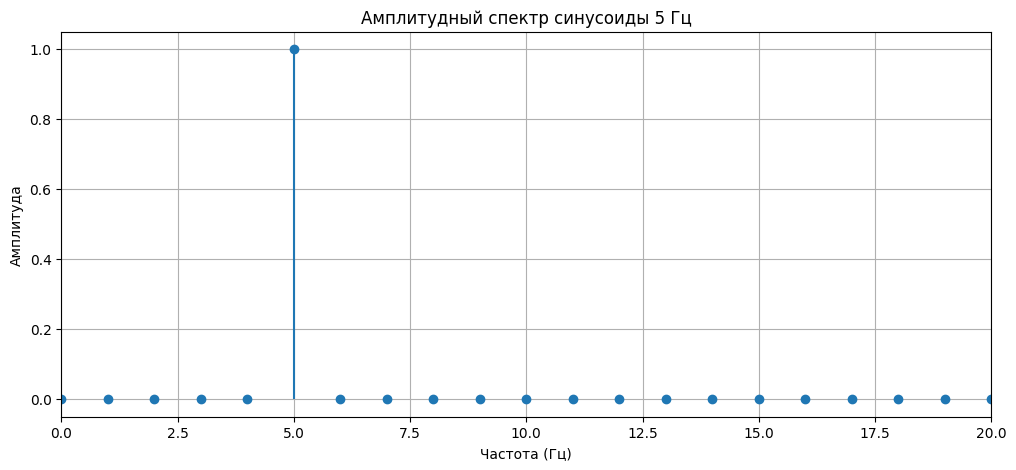

In [4]:
# БПФ синусоиды 5 Гц
X = np.fft.fft(sin5)
freq = np.fft.fftfreq(len(t), 1/fs)

half = len(t)//2
X_mag = np.abs(X[:half]) * 2 / len(t)
freq_pos = freq[:half]

plt.figure()
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку сигнал является чистой синусоидой одной частоты. Теоретическая амплитуда должна быть равна 1. Совпадает с полученной.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

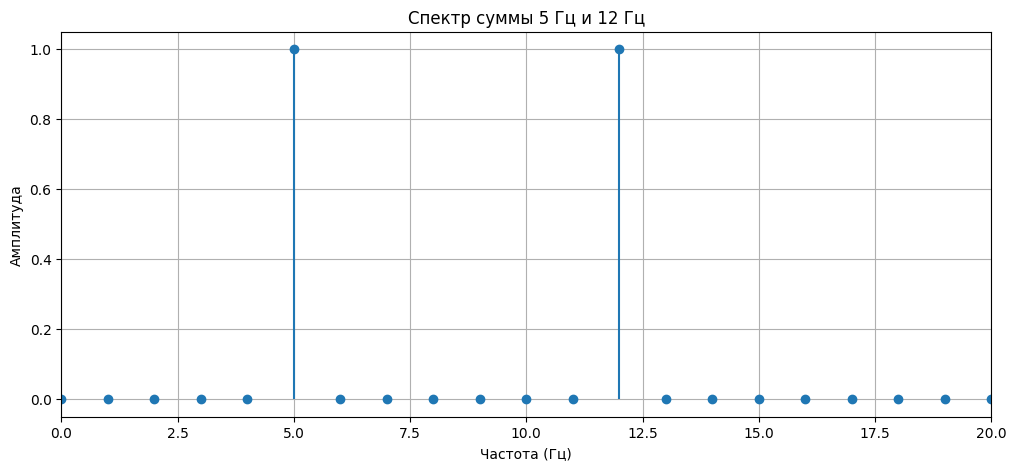

In [5]:
X_sum = np.fft.fft(sum_sin)
X_sum_mag = np.abs(X_sum[:half]) * 2 / len(t)

plt.figure()
plt.stem(freq_pos, X_sum_mag, basefmt=" ")
plt.title('Спектр суммы 5 Гц и 12 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, амплитудный спектр не изменится.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

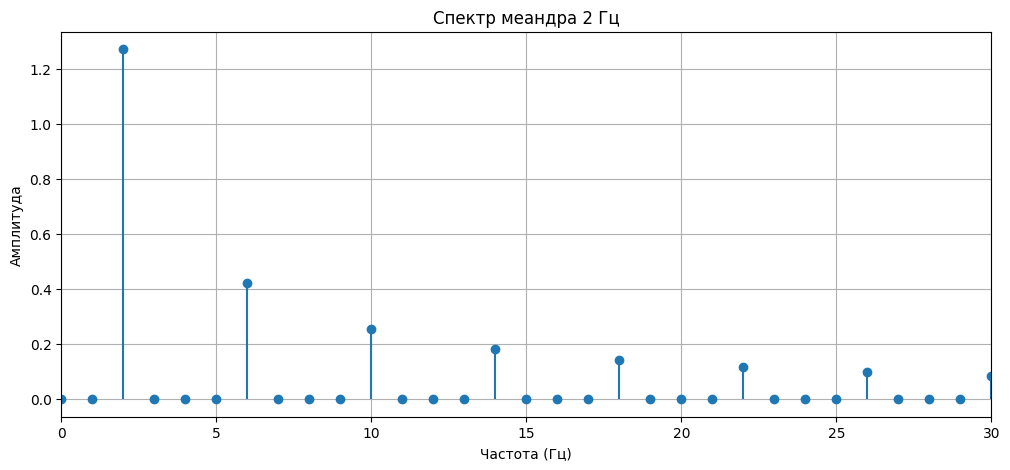

In [6]:
X_meander = np.fft.fft(meander)
X_meander_mag = np.abs(X_meander[:half]) * 2 / len(t)

plt.figure()
plt.stem(freq_pos[:100], X_meander_mag[:100], basefmt=" ")
plt.title('Спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()


**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку меандр является нечётной функцией и обладает симметрией, при которой чётные гармоники обращаются в ноль.

Теоретические амплитуды: 1-я (2 Гц): 1.273, 3-я (6 Гц): 0.424, 5-я (10 Гц): 0.255

Полученные амплитуды: 1.273, 0.424, 0.255

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

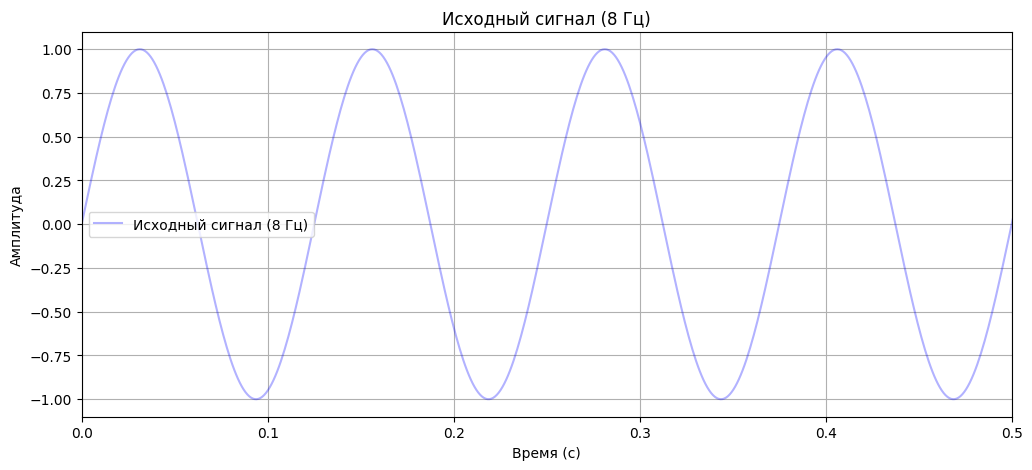

In [7]:
# «Аналоговый» сигнал с высокой частотой дискретизации
fs_analog = 1000
t_analog = np.linspace(0, 1, fs_analog)
f_signal = 8
analog_signal = np.sin(2 * np.pi * f_signal * t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал (8 Гц)')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

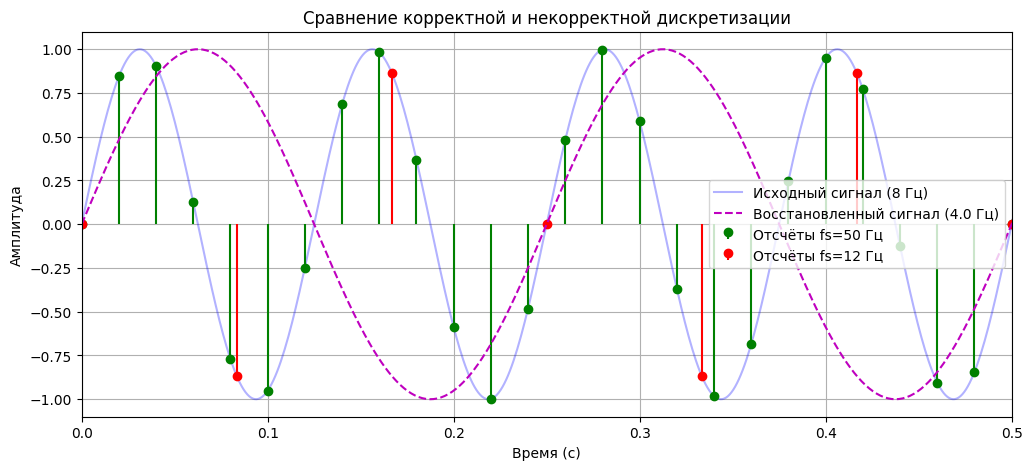

In [8]:
# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

t1 = np.arange(0, 1, 1/fs1)
samples1 = np.sin(2 * np.pi * f_signal * t1)

t2 = np.arange(0, 1, 1/fs2)
samples2 = np.sin(2 * np.pi * f_signal * t2)

f_alias = np.abs(f_signal - fs2 * round(f_signal/fs2))
if f_alias > fs2/2:
    f_alias = fs2 - f_alias
recovered = np.sin(2 * np.pi * f_alias * t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog, analog_signal, 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.stem(t1, samples1, linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')
plt.stem(t2, samples2, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')
plt.plot(t_analog, recovered, 'm--', label=f'Восстановленный сигнал ({f_alias:.1f} Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

При fs=12 Гц кажется, что присутствует частота 4.0 Гц. Она совпадает с теоретической: f_alias = |8 - 1·12| = 4.0 Гц.

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [9]:
def plot_aliasing(f_signal, f_sampling):
    t_cont = np.linspace(0, 0.5, 1000)
    t_samp = np.arange(0, 0.5, 1/f_sampling)

    signal_cont = np.sin(2 * np.pi * f_signal * t_cont)
    signal_samp = np.sin(2 * np.pi * f_signal * t_samp)

    f_alias = np.abs(f_signal - f_sampling * round(f_signal/f_sampling))
    if f_alias > f_sampling/2:
        f_alias = f_sampling - f_alias
    signal_recovered = np.sin(2 * np.pi * f_alias * t_cont)

    plt.figure(figsize=(12,4))
    plt.plot(t_cont, signal_cont, 'b-', alpha=0.3, label='Исходный сигнал')
    plt.stem(t_samp, signal_samp, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
    plt.plot(t_cont, signal_recovered, 'g--', label=f'Восстановленный ({f_alias:.1f} Гц)')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Частота сигнала = {f_signal} Гц, fs = {f_sampling} Гц')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.show()

widgets.interact(plot_aliasing,
         f_signal=widgets.FloatSlider(min=1, max=50, step=1, value=8),
         f_sampling=widgets.FloatSlider(min=5, max=100, step=1, value=50));

interactive(children=(FloatSlider(value=8.0, description='f_signal', max=50.0, min=1.0, step=1.0), FloatSlider…

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда частота сигнала близка к частоте дискретизации или её гармоникам.

Когда частота сигнала равна половине частоты дискретизации, восстановленный сигнал становится постоянным (нулевая частота).